# 1. Import Libraries

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Setup Successful")

Setup Successful


# 2. Load Dataset

In [ ]:
df = pd.read_excel("../data/Online Retail.xlsx")

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


# 3. Data Audit

In [6]:
# Dataset Shape
df.shape

(541909, 8)

In [7]:
# Column Names
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='str')

In [8]:
# Data Types
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 33.1+ MB


In [9]:
# Missing Values
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [10]:
# Duplicate Rows
df.duplicated().sum()

np.int64(5268)

In [11]:
# Statistical Summary
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


In [12]:
# Unique Customers
df['CustomerID'].nunique()

4372

In [13]:
# Date Range
print("Start Date:", df['InvoiceDate'].min())
print("End Date:", df['InvoiceDate'].max())

Start Date: 2010-12-01 08:26:00
End Date: 2011-12-09 12:50:00


# 4. Data Invastigation

In [14]:
# missing customer id's
df[df['CustomerID'].isna()].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,2010-12-01 11:52:00,0.00,NaN,United Kingdom
1443,536544,21773,DECORATIVE ROSE BATHROOM BOTTLE,1,2010-12-01 14:32:00,2.51,NaN,United Kingdom
1444,536544,21774,DECORATIVE CATS BATHROOM BOTTLE,2,2010-12-01 14:32:00,2.51,NaN,United Kingdom
1445,536544,21786,POLKADOT RAIN HAT,4,2010-12-01 14:32:00,0.85,NaN,United Kingdom
1446,536544,21787,RAIN PONCHO RETROSPOT,2,2010-12-01 14:32:00,1.66,NaN,United Kingdom


In [15]:
# negative quantities
df[df['Quantity'] < 0].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom


In [16]:
# zero prices
df[df['UnitPrice'] == 0].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,2010-12-01 11:52:00,0.0,NaN,United Kingdom
1970,536545,21134,NaN,1,2010-12-01 14:32:00,0.0,NaN,United Kingdom
1971,536546,22145,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1972,536547,37509,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1987,536549,85226A,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom


In [17]:
# invoice number starting with C
df[df['InvoiceNo'].astype(str).str.startswith('C')].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom


# 5 data cleaning 

In [18]:
# Analyst Decision Log

# A good analyst writes down decisions before cleaning.

# Decision 1

# Remove rows where CustomerID is missing.

# Reason:

# Customer cannot be identified.
# Not useful for segmentation.
# Decision 2

# Remove cancelled orders.

# Reason:

# We want actual purchasing behavior.
# Cancellations don't represent successful purchases.
# Decision 3

# Remove negative quantities.

# Reason:

# Returns/cancellations distort customer spending.
# Decision 4

# Remove duplicate rows.

# Reason:

# Avoid counting transactions twice.

In [19]:
# creating a working copy for the safety
df_clean = df.copy()

In [20]:
# remove missing customer id's 
df_clean = df_clean.dropna(subset=['CustomerID'])

# checking shape 
df_clean.shape

(406829, 8)

In [21]:
# removing cancelled orders
df_clean = df_clean[
    ~df_clean['InvoiceNo'].astype(str).str.startswith('C')
]

# check shape again

In [22]:
# removing negative quantities
df_clean = df_clean[df_clean['Quantity'] > 0]

# check shape again

In [23]:
# removing duplicates 
df_clean = df_clean.drop_duplicates()

# check shape again

In [24]:
# creating sales column
df_clean['Sales'] = (
    df_clean['Quantity'] *
    df_clean['UnitPrice']
)

In [25]:
# checking created column
df_clean.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Sales
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [26]:
# final validation
df_clean.info()

<class 'pandas.DataFrame'>
Index: 392732 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    392732 non-null  object        
 1   StockCode    392732 non-null  object        
 2   Description  392732 non-null  object        
 3   Quantity     392732 non-null  int64         
 4   InvoiceDate  392732 non-null  datetime64[us]
 5   UnitPrice    392732 non-null  float64       
 6   CustomerID   392732 non-null  float64       
 7   Country      392732 non-null  str           
 8   Sales        392732 non-null  float64       
dtypes: datetime64[us](1), float64(3), int64(1), object(3), str(1)
memory usage: 30.0+ MB


In [27]:
df_clean.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
Sales          0
dtype: int64

In [28]:
df_clean.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID,Sales
count,392732.000000,392732,392732.000000,392732.000000,392732.000000
mean,13.153718,2011-07-10 19:15:24.576301,3.125596,15287.734822,22.629195
min,1.000000,2010-12-01 08:26:00,0.000000,12346.000000,0.000000
25%,2.000000,2011-04-07 11:12:00,1.250000,13955.000000,4.950000
50%,6.000000,2011-07-31 12:02:00,1.950000,15150.000000,12.390000
75%,12.000000,2011-10-20 12:53:00,3.750000,16791.000000,19.800000
max,80995.000000,2011-12-09 12:50:00,8142.750000,18287.000000,168469.600000
std,181.588420,NaN,22.240725,1713.567773,311.083465


# 6 Exploratory Data Analysis (EDA)

In [29]:
# 1.What is the total revenue?
df_clean['Sales'].sum()

np.float64(8887208.894)

In [30]:
# 2. How many unique customers do we have after cleaning?
df_clean['CustomerID'].nunique()

4339

In [31]:
# 3. How many unique orders?
df_clean['InvoiceNo'].nunique()

18536

In [32]:
# 4. Average Order Value
#First create invoice-level sales:
invoice_sales = df_clean.groupby('InvoiceNo')['Sales'].sum()

In [33]:
invoice_sales.mean()

np.float64(479.45667317652135)

In [34]:
#Top 10 Customers by Revenue
top_customers = (
    df_clean.groupby('CustomerID')['Sales']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_customers

CustomerID
14646.0    280206.02
18102.0    259657.30
17450.0    194390.79
16446.0    168472.50
14911.0    143711.17
12415.0    124914.53
14156.0    117210.08
17511.0     91062.38
16029.0     80850.84
12346.0     77183.60
Name: Sales, dtype: float64

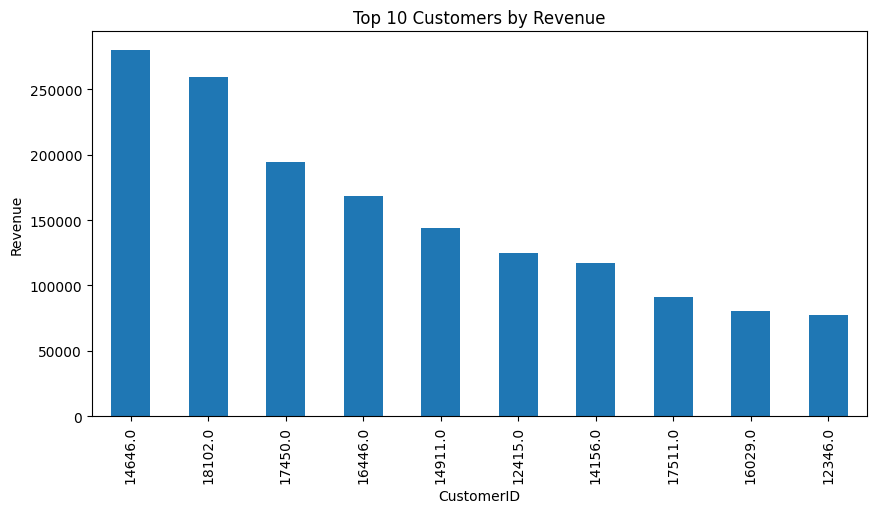

In [38]:
# first visualization
plt.figure(figsize=(10,5))

top_customers.plot(kind='bar')

plt.title('Top 10 Customers by Revenue')
plt.ylabel('Revenue')
plt.show()

In [54]:
# revenue trend over time
df_clean['YearMonth'] = (
    df_clean['InvoiceDate']
    .dt.to_period('M')
)

df_clean['YearMonth']

0         2010-12
1         2010-12
2         2010-12
3         2010-12
4         2010-12
           ...   
541904    2011-12
541905    2011-12
541906    2011-12
541907    2011-12
541908    2011-12
Name: YearMonth, Length: 392732, dtype: period[M]

In [ ]:
# monthly sales
monthly_sales = (
    df_clean
    .groupby('YearMonth')['Sales']
    .sum()
)

monthly_sales

YearMonth
2010-12     570422.730
2011-01     568101.310
2011-02     446084.920
2011-03     594081.760
2011-04     468374.331
2011-05     677355.150
2011-06     660046.050
2011-07     598962.901
2011-08     644051.040
2011-09     950690.202
2011-10    1035642.450
2011-11    1156205.610
2011-12     517190.440
Freq: M, Name: Sales, dtype: float64

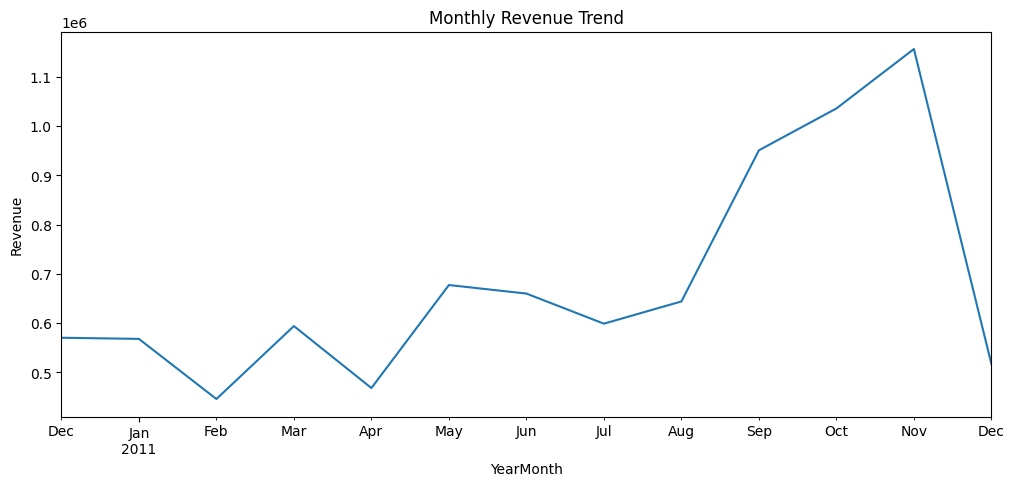

In [44]:
# plot
plt.figure(figsize=(12,5))

monthly_sales.plot()

plt.title('Monthly Revenue Trend')
plt.ylabel('Revenue')
plt.show()

In [45]:
# top countries by revenue
country_sales = (
    df_clean
    .groupby('Country')['Sales']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

country_sales

Country
United Kingdom    7285024.644
Netherlands        285446.340
EIRE               265262.460
Germany            228678.400
France             208934.310
Australia          138453.810
Spain               61558.560
Switzerland         56443.950
Belgium             41196.340
Sweden              38367.830
Name: Sales, dtype: float64

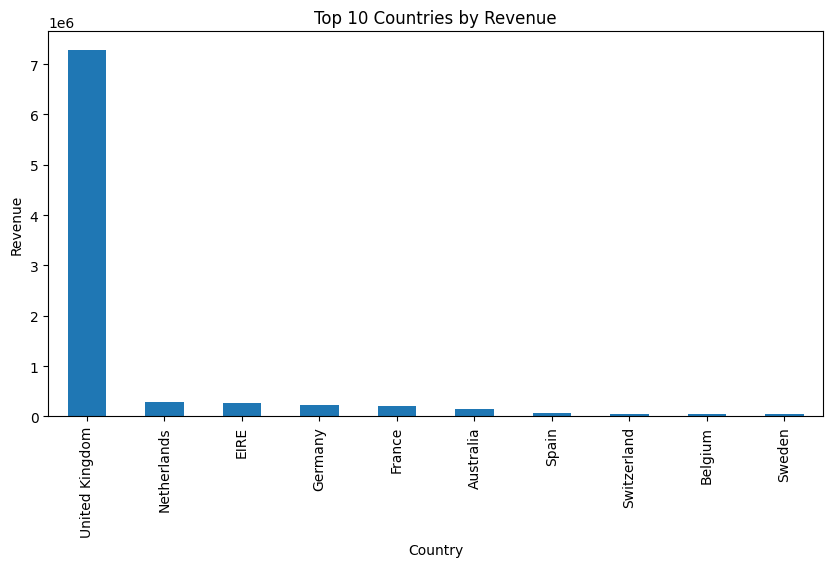

In [46]:
#plot
plt.figure(figsize=(10,5))

country_sales.plot(kind='bar')

plt.title('Top 10 Countries by Revenue')
plt.ylabel('Revenue')
plt.show()

In [48]:
# revenue distribution
customer_revenue = (
    df_clean
    .groupby('CustomerID')['Sales']
    .sum()
)

customer_revenue

CustomerID
12346.0    77183.60
12347.0     4310.00
12348.0     1797.24
12349.0     1757.55
12350.0      334.40
             ...   
18280.0      180.60
18281.0       80.82
18282.0      178.05
18283.0     2045.53
18287.0     1837.28
Name: Sales, Length: 4339, dtype: float64

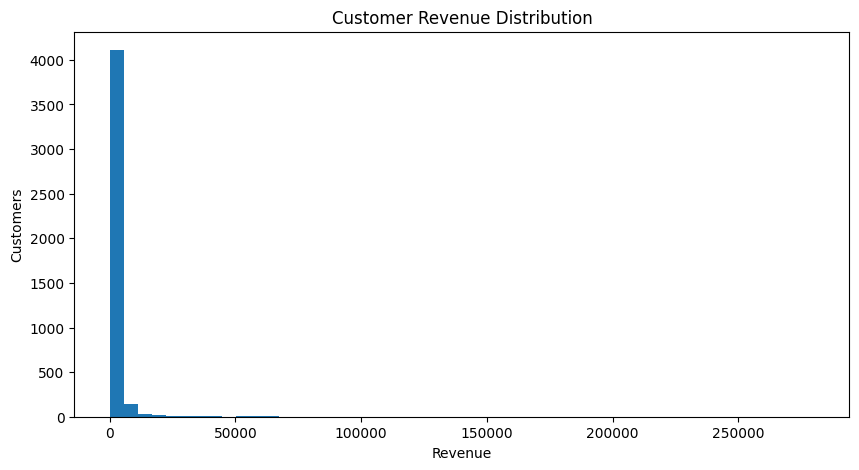

In [49]:
#plot
plt.figure(figsize=(10,5))

plt.hist(customer_revenue, bins=50)

plt.title('Customer Revenue Distribution')
plt.xlabel('Revenue')
plt.ylabel('Customers')

plt.show()

In [51]:
#Purchase Frequency Distribution
customer_frequency = (
    df_clean
    .groupby('CustomerID')['InvoiceNo']
    .nunique()
)

customer_frequency

CustomerID
12346.0     1
12347.0     7
12348.0     4
12349.0     1
12350.0     1
           ..
18280.0     1
18281.0     1
18282.0     2
18283.0    16
18287.0     3
Name: InvoiceNo, Length: 4339, dtype: int64

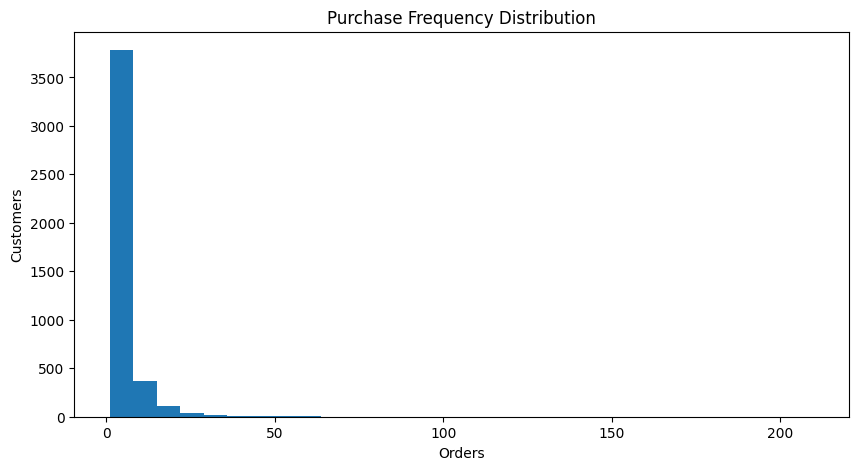

In [52]:
#plot
plt.figure(figsize=(10,5))

plt.hist(customer_frequency, bins=30)

plt.title('Purchase Frequency Distribution')
plt.xlabel('Orders')
plt.ylabel('Customers')

plt.show()

# 7 Customer Metrics

In [56]:
#customer levvel database
customer_df = (
    df_clean
    .groupby('CustomerID')
    .agg({
        'InvoiceDate':'max',
        'InvoiceNo':'nunique',
        'Sales':'sum'
    })
)

customer_df.head()

,InvoiceDate,InvoiceNo,Sales
CustomerID,,,
12346.0,2011-01-18 10:01:00,1,77183.60
12347.0,2011-12-07 15:52:00,7,4310.00
12348.0,2011-09-25 13:13:00,4,1797.24
12349.0,2011-11-21 09:51:00,1,1757.55
12350.0,2011-02-02 16:01:00,1,334.40


In [67]:
# renaming the columns
customer_df.columns = [
    'LastPurchaseDate',
    'Frequency',
    'Monetary'
]

customer_df.head()

,LastPurchaseDate,Frequency,Monetary
CustomerID,,,
12346.0,2011-01-18 10:01:00,1,77183.60
12347.0,2011-12-07 15:52:00,7,4310.00
12348.0,2011-09-25 13:13:00,4,1797.24
12349.0,2011-11-21 09:51:00,1,1757.55
12350.0,2011-02-02 16:01:00,1,334.40


In [64]:
# Create Recency 
# defining analysis date.
snapshot_date = (
    df_clean['InvoiceDate'].max()
    + pd.Timedelta(days=1)
)

snapshot_date

Timestamp('2011-12-10 12:50:00')

In [68]:
# Recency calculation
customer_df['Recency'] = (
    snapshot_date
    - customer_df['LastPurchaseDate']
).dt.days

In [69]:
#reordering the columns
customer_df = customer_df[
    [
        'Recency',
        'Frequency',
        'Monetary'
    ]
]

customer_df.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


In [70]:
customer_df.describe()

,Recency,Frequency,Monetary
count,4339.000000,4339.000000,4339.000000
mean,92.518322,4.271952,2048.215924
std,100.009747,7.705493,8984.248352
min,1.000000,1.000000,0.000000
25%,18.000000,1.000000,306.455000
50%,51.000000,2.000000,668.560000
75%,142.000000,5.000000,1660.315000
max,374.000000,210.000000,280206.020000


In [ ]:
# Analysis Before Scoring
# Recency
# Metric	Value
# Min	1 day
# Median	51 days
# Mean	92.5 days
# Max	374 days
# Insight
# Some customers purchased just 1 day before the snapshot date.
# Some customers haven't purchased for over a year.
# Median (51 days) is much lower than mean (92 days), meaning there are many inactive customers pulling the average up.

# Business meaning:

# We have a significant number of inactive customers that may require re-engagement campaigns.

# Frequency
# Metric	Value
# Min	1
# Median	2
# Mean	4.27
# Max	210
# Insight

# This is huge.

# Half of all customers placed only:

# 2 orders or fewer

# while one customer placed:

# 210 orders

# Business meaning:

# Customer purchase frequency is highly uneven, with a small group of highly engaged customers generating repeated transactions.

# Monetary
# Metric	Value
# Min	0
# Median	668
# Mean	2048
# Max	280,206
# Insight

# This is extremely skewed.

# Median:

# 668

# Mean:

# 2048

# One customer:

# 280,206

# spent more than many customers combined.

# Business meaning:

# Revenue is concentrated among a small group of high-value customers, highlighting the importance of identifying and retaining top spenders.

# 8 RFM Analysis

In [71]:
#Create R Score
# Lower Recency = Better
customer_df['R_Score'] = pd.qcut(
    customer_df['Recency'],
    q=5,
    labels=[5,4,3,2,1]
)

In [72]:
# Create F Score
# Higher Frequency = Better
customer_df['F_Score'] = pd.qcut(
    customer_df['Frequency'].rank(method='first'),
    q=5,
    labels=[1,2,3,4,5]
)

In [73]:
# Create M Score
# Higher Monetary = Better
customer_df['M_Score'] = pd.qcut(
    customer_df['Monetary'],
    q=5,
    labels=[1,2,3,4,5]
)

In [75]:
#cheching the scores
customer_df.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score
CustomerID,,,,,,
12346.0,326,1,77183.60,1,1,5
12347.0,2,7,4310.00,5,5,5
12348.0,75,4,1797.24,2,4,4
12349.0,19,1,1757.55,4,1,4
12350.0,310,1,334.40,1,1,2


In [78]:
#overall RFM score
customer_df['RFM_Score'] = (
    customer_df['R_Score'].astype(str)
    + customer_df['F_Score'].astype(str)
    + customer_df['M_Score'].astype(str)
)

In [79]:
customer_df[['RFM_Score']].head()

,RFM_Score
CustomerID,
12346.0,115
12347.0,555
12348.0,244
12349.0,414
12350.0,112


In [80]:
customer_df[['R_Score','F_Score','M_Score']].describe()

,R_Score,F_Score,M_Score
count,4339,4339,4339
unique,5,5,5
top,4,1,1
freq,905,868,868


In [81]:
customer_df['RFM_Score'].value_counts().head(10)

RFM_Score
555    347
111    182
455    177
121    153
112    127
444    119
122     91
544     85
233     83
344     82
Name: count, dtype: int64

In [82]:
customer_df.head(10)

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
CustomerID,,,,,,,
12346.0,326,1,77183.60,1,1,5,115
12347.0,2,7,4310.00,5,5,5,555
12348.0,75,4,1797.24,2,4,4,244
12349.0,19,1,1757.55,4,1,4,414
12350.0,310,1,334.40,1,1,2,112
12352.0,36,8,2506.04,3,5,5,355
12353.0,204,1,89.00,1,1,1,111
12354.0,232,1,1079.40,1,1,4,114
12355.0,214,1,459.40,1,1,2,112


# 9 Customer Segmentation

In [83]:
def segment_customer(row):

    if row['R_Score'] >= 4 and row['F_Score'] >= 4 and row['M_Score'] >= 4:
        return 'Champions'

    elif row['R_Score'] >= 3 and row['F_Score'] >= 3:
        return 'Loyal Customers'

    elif row['R_Score'] >= 4:
        return 'Potential Loyalists'

    elif row['R_Score'] <= 2 and row['F_Score'] >= 3:
        return 'At Risk'

    else:
        return 'Lost Customers'

In [84]:
customer_df['Segment'] = customer_df.apply(
    segment_customer,
    axis=1
)

In [ ]:
#segment count
customer_df['Segment'].value_counts()

Segment
Lost Customers         1416
Loyal Customers        1002
Champions               958
At Risk                 643
Potential Loyalists     320
Name: count, dtype: int64

In [86]:
#segment percentage
segment_pct = (
    customer_df['Segment']
    .value_counts(normalize=True)
    * 100
)

segment_pct

Segment
Lost Customers         32.634248
Loyal Customers        23.092879
Champions              22.078820
At Risk                14.819083
Potential Loyalists     7.374971
Name: proportion, dtype: float64

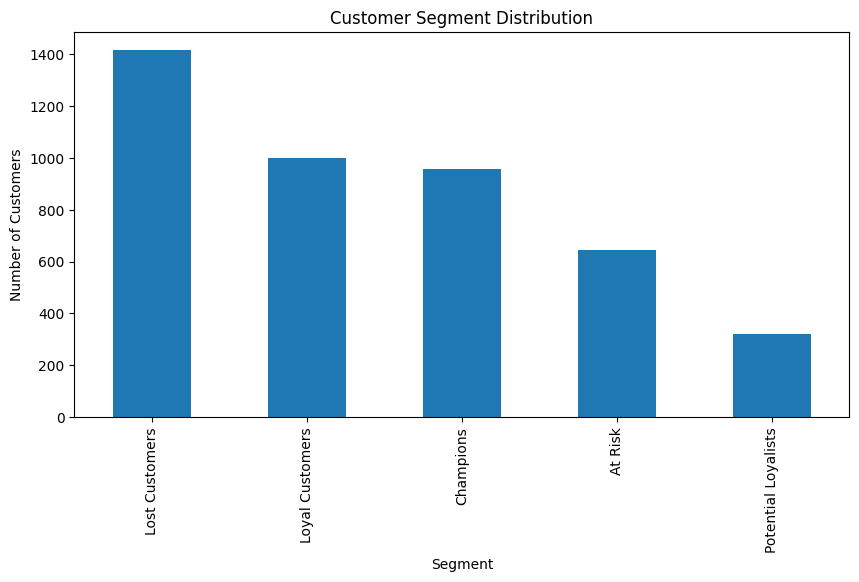

In [ ]:
#segment distribution
plt.figure(figsize=(10,5))

customer_df['Segment'].value_counts().plot(
    kind='bar'
)

plt.title('Customer Segment Distribution')
plt.xlabel('Segment')
plt.ylabel('Number of Customers')

plt.show()

In [89]:
#revenue by segment 
segment_revenue = (
    customer_df
    .groupby('Segment')['Monetary']
    .sum()
    .sort_values(ascending=False)
)

segment_revenue

Segment
Champions              5792574.000
Loyal Customers        1471932.381
At Risk                 798052.511
Lost Customers          679430.262
Potential Loyalists     145219.740
Name: Monetary, dtype: float64

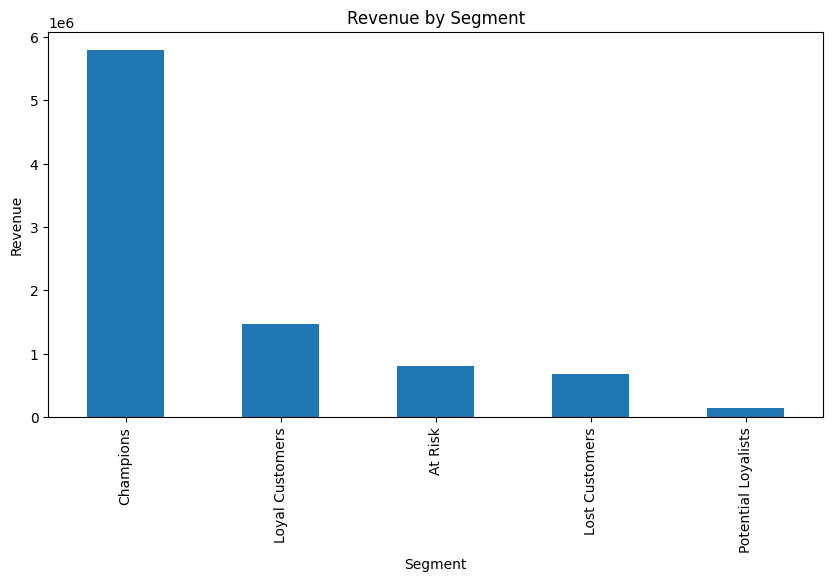

In [90]:
plt.figure(figsize=(10,5))

segment_revenue.plot(
    kind='bar'
)

plt.title('Revenue by Segment')
plt.ylabel('Revenue')

plt.show()

In [91]:
segment_pct

Segment
Lost Customers         32.634248
Loyal Customers        23.092879
Champions              22.078820
At Risk                14.819083
Potential Loyalists     7.374971
Name: proportion, dtype: float64

# 10 business insights and recommendations

<!--
Business Insights

Key Findings

Generated approximately 8.89 million in total revenue from 18,536 orders across 4,339 customers.
Revenue increased throughout the year and peaked in November, indicating strong seasonal growth.
The United Kingdom contributed the majority of sales revenue, highlighting heavy dependence on a single market.
Customer spending distribution was highly skewed, with a small group of customers generating a significant share of revenue.
More than 32% of customers were classified as Lost Customers, indicating opportunities for retention initiatives.
Champions and Loyal Customers represented 45% of the customer base and contributed the largest share of revenue.
Customer purchase behavior showed that most customers placed only a small number of orders, while a limited group exhibited strong repeat-purchase behavior.

Recommendations

Champions

VIP rewards program
Exclusive product access
Loyalty incentives

Loyal Customers

Cross-selling campaigns
Product bundles
Reward points program

Potential Loyalists

Personalized promotions
Follow-up marketing campaigns

At Risk Customers

Re-engagement emails
Special offers
Time-limited incentives

Lost Customers

Win-back campaigns
Buy-one-get-one offers
High-value discount promotions
 -->